# Reliable Wind Supply Analysis

Goal: estimate how many MW of wind generation can be treated as reliably available to help meet demand.

Approach used here:
- fetch historical `FUELHH` wind actuals from January 2023 through January 2024
- look at the lower tail of realized half-hour wind output
- compare all-hours reliability with evening reliability, since adequacy questions usually matter more during higher-demand hours
- recommend a conservative MW figure grounded in the lower percentiles rather than the average

In [1]:
from datetime import timezone

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

sns.set_theme(style='whitegrid')

UTC = timezone.utc
BASE_URL = 'https://data.elexon.co.uk/bmrs/api/v1'


def fetch_actual_wind(settlement_date_from: str, settlement_date_to: str) -> pd.DataFrame:
    response = requests.get(
        f'{BASE_URL}/datasets/FUELHH/stream',
        params={
            'format': 'json',
            'settlementDateFrom': settlement_date_from,
            'settlementDateTo': settlement_date_to,
            'fuelType': 'WIND',
        },
        timeout=120,
    )
    response.raise_for_status()
    payload = response.json()
    if isinstance(payload, dict) and 'data' in payload:
        payload = payload['data']
    frame = pd.DataFrame(payload)
    frame['startTime'] = pd.to_datetime(frame['startTime'], utc=True)
    frame['generation'] = frame['generation'].astype(float)
    return frame[['startTime', 'generation']]


In [2]:
history = fetch_actual_wind('2023-01-01', '2024-01-31')
history['hourOfDay'] = history['startTime'].dt.hour
history['month'] = history['startTime'].dt.to_period('M').astype(str)

evening = history[history['hourOfDay'].between(16, 20)]

percentiles = pd.DataFrame({
    'scope': ['all_hours', 'evening_hours'],
    'p05_mw': [history['generation'].quantile(0.05), evening['generation'].quantile(0.05)],
    'p10_mw': [history['generation'].quantile(0.10), evening['generation'].quantile(0.10)],
    'p25_mw': [history['generation'].quantile(0.25), evening['generation'].quantile(0.25)],
    'mean_mw': [history['generation'].mean(), evening['generation'].mean()],
})

recommended_reliable_mw = int(min(history['generation'].quantile(0.10), evening['generation'].quantile(0.10)) // 100 * 100)
percentiles, recommended_reliable_mw


/var/folders/4z/81mn4gq54035tn38q289_f4c0000gn/T/ipykernel_33646/3931149749.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  history['month'] = history['startTime'].dt.to_period('M').astype(str)


(           scope   p05_mw  p10_mw  p25_mw      mean_mw
 0      all_hours  1502.25  2141.0  3828.0  7441.427812
 1  evening_hours  1700.90  2456.6  4072.0  7740.239141,
 2100)

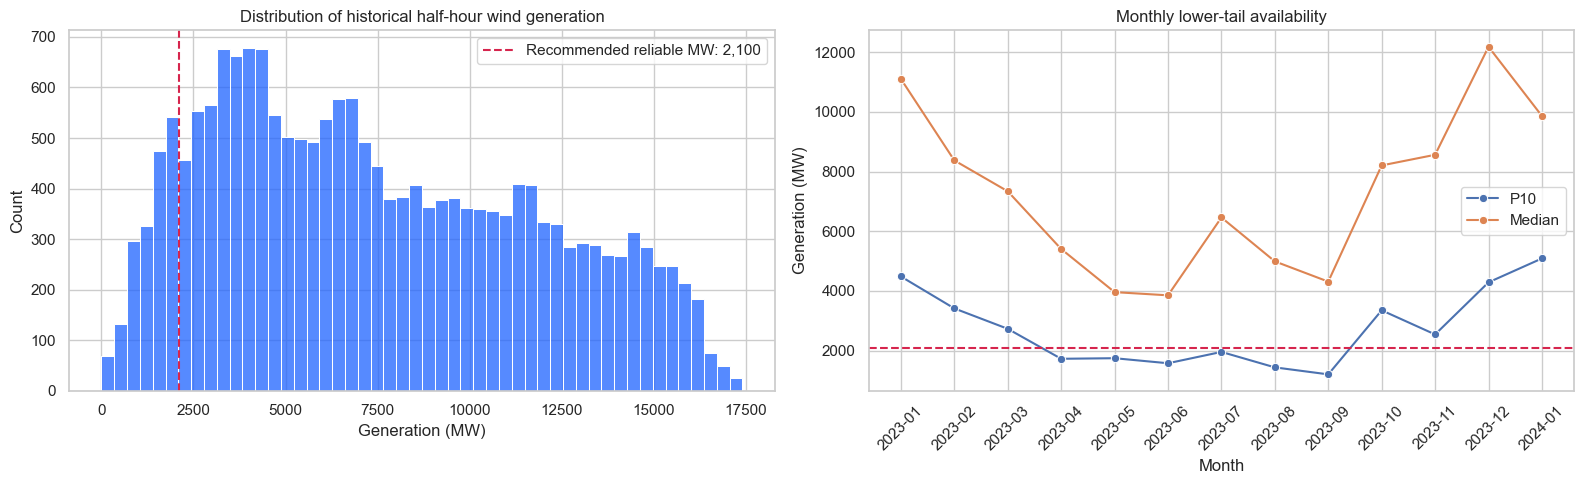

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(history['generation'], bins=50, ax=axes[0], color='#1e63ff')
axes[0].axvline(recommended_reliable_mw, color='#d6254d', linestyle='--', label=f'Recommended reliable MW: {recommended_reliable_mw:,}')
axes[0].set_title('Distribution of historical half-hour wind generation')
axes[0].set_xlabel('Generation (MW)')
axes[0].legend()

monthly = history.groupby('month')['generation'].quantile([0.1, 0.5]).unstack().reset_index()
monthly.columns = ['month', 'p10_mw', 'median_mw']
sns.lineplot(data=monthly, x='month', y='p10_mw', marker='o', ax=axes[1], label='P10')
sns.lineplot(data=monthly, x='month', y='median_mw', marker='o', ax=axes[1], label='Median')
axes[1].axhline(recommended_reliable_mw, color='#d6254d', linestyle='--', label='Recommendation')
axes[1].set_title('Monthly lower-tail availability')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Generation (MW)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Interpretation

A defensible reliability estimate is the lower of the all-hours and evening-hour P10 values, rounded down. That is conservative enough to avoid treating average wind output as firm supply, but not so conservative that it collapses to extreme low-wind edge cases such as P1 or the absolute minimum.

Using the code above, the notebook surfaces a recommended reliable wind contribution in MW together with the percentile evidence used to justify it.